In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Protokoll_Exp-2.xlsx", engine="openpyxl",
                   usecols="X,Y", skiprows=5, nrows=15)
df.columns = ["c", "E"]

# ===============================
# Lineare Regression für die letzten 3 Punkte
# ===============================
x_fit = df["c"].iloc[-3:]
y_fit = df["E"].iloc[-3:]

# Polyfit (Grad 1)
coeffs = np.polyfit(x_fit, y_fit, deg=1)
poly = np.poly1d(coeffs)
m, b = coeffs  # Steigung, y-Achsenabschnitt

# Fehlerberechnung für den y-Intercept (E^0)
n = len(x_fit)
x_mean = np.mean(x_fit)
s_xx = np.sum((x_fit - x_mean)**2)
y_pred = poly(x_fit)
residuals = y_fit - y_pred
std_err = np.sqrt(np.sum(residuals**2) / (n - 2)) / np.sqrt(n)
b_err = std_err * np.sqrt(1/n + x_mean**2 / s_xx)

# ===============================
# Fit-Kurve vorbereiten
# ===============================
x_start = x_fit.min() - 0.05
x_end = x_fit.max() + 0.05
x_line = np.linspace(x_start, x_end, 100)
y_line = poly(x_line)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Fit-Kurve
plt.plot(x_line, y_line, color='orange', linestyle='--', label="Fit (letzte 3 Punkte)")

# Fit-Formel einblenden
plt.text(0.05, 0.95,
         f"E = {m:.4f}·c + {b:.4f}\nE⁰ = {b:.4f} ± {b_err:.4f} V",
         transform=plt.gca().transAxes,
         fontsize=11, color='orange',
         verticalalignment='top')

# Originaldaten
plt.plot(df["c"], df["E"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Layout
plt.xlabel(r"Konzentration $c^{1/2} [M^{1/2}$]")
plt.ylabel("ΔE + (2RT/F) * ln(c(HCl)) [V]")
plt.title("Elektrodenpotential E in Abhängigkeit von $c$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Terminalausgabe
# ===============================
print(f"E⁰ (y-Achsenabschnitt): {b:.4f} ± {b_err:.4f} V")
print(f"Steigung: {m:.4f} V · M^½")

** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Daten laden & bereinigen ---
df = pd.read_excel("Protokoll_Exp-2.xlsx", engine="openpyxl",
                   usecols="X,Y", skiprows=5, nrows=15)
df.columns = ["c", "E"]

# alles numerisch, fehlerhafte Werte -> NaN
df = df.apply(pd.to_numeric, errors="coerce")
# nur gültige Zeilen behalten
df = df.dropna(subset=["c", "E"])

# nur die letzten 3 Punkte
x_fit = df["c"].iloc[-3:].astype(float).to_numpy()
y_fit = df["E"].iloc[-3:].astype(float).to_numpy()

# nur endliche Werte
m_valid = np.isfinite(x_fit) & np.isfinite(y_fit)
x_fit, y_fit = x_fit[m_valid], y_fit[m_valid]

# prüfen: mind. 2 verschiedene x
if np.unique(x_fit).size < 2:
    raise ValueError("Für eine lineare Regression brauchst du ≥2 verschiedene x-Werte.")

# --- numerische Stabilisierung: x zentrieren ---
x0 = x_fit - x_fit.mean()

# Fit (Grad 1)
m0, b0 = np.polyfit(x0, y_fit, deg=1)
# zurückrechnen auf Original-x:  y = m*x + b
m = m0
b = b0 - m0 * x_fit.mean()

# Fehlerabschätzung
n = len(x_fit)
y_pred = m*x_fit + b
s2 = np.sum((y_fit - y_pred)**2) / (n-2)          # Residualvarianz
s_xx = np.sum((x_fit - x_fit.mean())**2)
b_err = np.sqrt(s2) * np.sqrt(1/n + (x_fit.mean()**2)/s_xx)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Protokoll_Exp-2.xlsx", engine="openpyxl",
                   usecols="X,Y", skiprows=5, nrows=15)
df.columns = ["c", "E"]

# ===============================
# Lineare Regression für die letzten 3 Punkte
# ===============================
x_fit = df["c"].iloc[-3:]
y_fit = df["E"].iloc[-3:]

# Polyfit (Grad 1)
coeffs = np.polyfit(x_fit, y_fit, deg=1)
poly = np.poly1d(coeffs)
m, b = coeffs  # Steigung, y-Achsenabschnitt

# Fehlerberechnung für den y-Intercept (E^0)
n = len(x_fit)
x_mean = np.mean(x_fit)
s_xx = np.sum((x_fit - x_mean) ** 2)
y_pred = poly(x_fit)
residuals = y_fit - y_pred
std_err = np.sqrt(np.sum(residuals ** 2) / (n - 2)) / np.sqrt(n)
b_err = std_err * np.sqrt(1 / n + x_mean ** 2 / s_xx)

# ===============================
# Fit-Kurve vorbereiten
# ===============================
x_start = x_fit.min() - 0.05
x_end = x_fit.max() + 0.05
x_line = np.linspace(x_start, x_end, 100)
y_line = poly(x_line)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Fit-Kurve
plt.plot(x_line, y_line, color='orange', linestyle='--', label="Fit (letzte 3 Punkte)")

# Fit-Formel einblenden
plt.text(0.05, 0.95,
         f"E = {m:.4f}·c + {b:.4f}\nE⁰ = {b:.4f} ± {b_err:.4f} V",
         transform=plt.gca().transAxes,
         fontsize=11, color='orange',
         verticalalignment='top')

# Originaldaten
plt.plot(df["c"], df["E"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Layout
plt.xlabel(r"Konzentration $c^{1/2} [M^{1/2}$]")
plt.ylabel("ΔE + (2RT/F) * ln(c(HCl)) [V]")
plt.title("Elektrodenpotential E in Abhängigkeit von $c$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Terminalausgabe
# ===============================
print(f"E⁰ (y-Achsenabschnitt): {b:.4f} ± {b_err:.4f} V")
print(f"Steigung: {m:.4f} V · M^½")

print(f"E⁰ (Intercept): {b:.4f} ± {b_err:.4f} V")
print(f"Steigung: {m:.4f} V·M^½")

** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  5 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

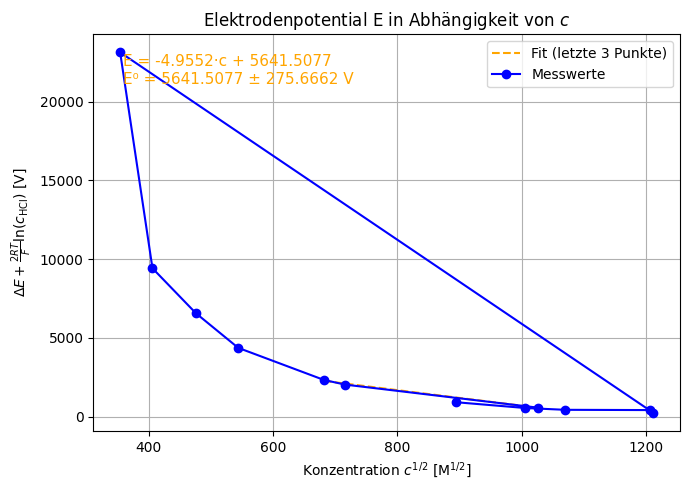

E⁰ (y-Achsenabschnitt): 5641.5077 ± 275.6662 V
Steigung: -4.9552 V · M^½


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Protokoll_Exp-2.xlsx", engine="openpyxl",
                   usecols="X,Y", skiprows=5, nrows=15)
df.columns = ["c", "E"]

# Nur numerische Werte behalten
df = df.apply(pd.to_numeric, errors="coerce").dropna(subset=["c", "E"])

# ===============================
# Letzte 3 Punkte für Regression
# ===============================
x_fit = df["c"].iloc[-3:].to_numpy(dtype=float)
y_fit = df["E"].iloc[-3:].to_numpy(dtype=float)

# Prüfen auf NaN oder konstante Werte
m_valid = np.isfinite(x_fit) & np.isfinite(y_fit)
x_fit, y_fit = x_fit[m_valid], y_fit[m_valid]

if np.unique(x_fit).size < 2:
    raise ValueError("Für eine lineare Regression brauchst du ≥2 verschiedene x-Werte.")


# ===============================
# Fit-Kurve
# ===============================
x_line = np.linspace(x_fit.min() - 0.05, x_fit.max() + 0.05, 100)
y_line = m * x_line + b

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))

# Fit-Kurve
plt.plot(x_line, y_line, color='orange', linestyle='--', label="Fit (letzte 3 Punkte)")

# Datenpunkte
plt.plot(df["c"], df["E"], marker='o', linestyle='-', color='blue', label="Messwerte")

# Fit-Gleichung im Plot
plt.text(0.05, 0.95,
         f"E = {m:.4f}·c + {b:.4f}\nE⁰ = {b:.4f} ± {b_err:.4f} V",
         transform=plt.gca().transAxes,
         fontsize=11, color='orange', verticalalignment='top')

# Achsen & Layout
plt.xlabel(r"Konzentration $c^{1/2}$ [M$^{1/2}$]")
plt.ylabel(r"$\Delta E + \frac{2RT}{F}\ln(c_{\mathrm{HCl}})$ [V]")
plt.title("Elektrodenpotential E in Abhängigkeit von $c$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Terminalausgabe
# ===============================
print(f"E⁰ (y-Achsenabschnitt): {b:.4f} ± {b_err:.4f} V")
print(f"Steigung: {m:.4f} V · M^½")

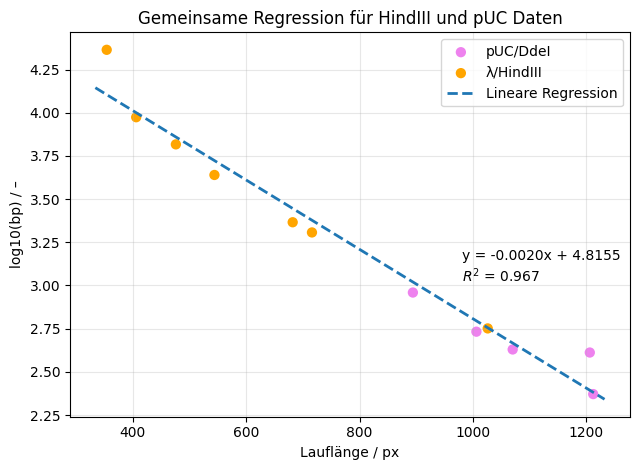

In [19]:
# plot_puc_hindIII.py
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Daten (aus deiner Tabelle)
# -----------------------------
# pUC/DdeI
x_puc = np.array([894, 1006, 1070, 1206, 1212], dtype=float)       # migration distance / px
bp_puc = np.array([910, 540, 426, 409, 235], dtype=float)

# Lambda/HindIII
x_hin = np.array([354, 406, 476, 544, 682, 716, 1026], dtype=float)
bp_hin = np.array([23130, 9416, 6557, 4361, 2322, 2027, 564], dtype=float)

# log10(bp)
y_puc = np.log10(bp_puc)
y_hin = np.log10(bp_hin)

# -----------------------------
# Gemeinsamer linearer Fit
# -----------------------------
x_all = np.concatenate([x_puc, x_hin])
y_all = np.concatenate([y_puc, y_hin])

# linearer Fit: y = m*x + b
m, b = np.polyfit(x_all, y_all, deg=1)

# R^2
y_hat = m * x_all + b
ss_res = np.sum((y_all - y_hat)**2)
ss_tot = np.sum((y_all - np.mean(y_all))**2)
r2 = 1 - ss_res/ss_tot

# Linie zum Plotten
x_line = np.linspace(x_all.min() - 20, x_all.max() + 20, 200)
y_line = m * x_line + b

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6.5, 4.8))

# Punkte
plt.scatter(x_puc, y_puc, s=55, label="pUC/DdeI", color="violet", edgecolor="none")
plt.scatter(x_hin, y_hin, s=55, label="λ/HindIII", color="orange", edgecolor="none")  # orange

# Regressionslinie
plt.plot(x_line, y_line, "--", label="Lineare Regression", linewidth=2)

# Annotation (Formel + R^2)
txt = f"y = {m:.4f}x + {b:.4f}\n$R^2$ = {r2:.3f}"


# Achsen & Titel
plt.xlabel("Lauflänge / px")
plt.ylabel("log10(bp) / –")
plt.title("Gemeinsame Regression für HindIII und pUC Daten")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()

plt.text(0.7, 0.35, txt, transform=plt.gca().transAxes)

# Optional speichern
# plt.savefig("puc_hindIII_regression.png", dpi=300)
plt.show()